In [ ]:
!pip uninstall -y protobuf
!pip install protobuf==3.20.3 --quiet
print("Protobuf downgraded to 3.20.3 - compatible with TensorFlow")

Found existing installation: protobuf 6.33.0
Uninstalling protobuf-6.33.0:
  Successfully uninstalled protobuf-6.33.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 3.5 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.2

In [ ]:
import os
import gc
import glob
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import MultiHeadAttention

2026-01-17 01:37:45.708354: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768613865.733816      78 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768613865.741841      78 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768613865.761837      78 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768613865.761878      78 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768613865.761881      78 computation_placer.cc:177] computation placer alr

In [ ]:
# 1. PREPROCESS: RE-SPLIT DỮ LIỆU (Giống file gốc của bạn)
print(">>> ĐANG THỰC HIỆN PREPROCESS: RE-SPLIT DỮ LIỆU...")

BASE_PATH = '/kaggle/input/chest-xray-pneumonia/chest_xray'
train_normal = glob.glob(os.path.join(BASE_PATH, 'train/NORMAL/*.jpeg'))
train_pneu   = glob.glob(os.path.join(BASE_PATH, 'train/PNEUMONIA/*.jpeg'))
val_normal   = glob.glob(os.path.join(BASE_PATH, 'val/NORMAL/*.jpeg'))
val_pneu     = glob.glob(os.path.join(BASE_PATH, 'val/PNEUMONIA/*.jpeg'))

all_normal = train_normal + val_normal
all_pneu   = train_pneu + val_pneu

df_normal = pd.DataFrame({'path': all_normal, 'label': 'NORMAL'})
df_pneu   = pd.DataFrame({'path': all_pneu, 'label': 'PNEUMONIA'})
df_merged = pd.concat([df_normal, df_pneu], ignore_index=True)

# Chia tập 80% Train - 20% Val (Stratified để cân bằng lớp)
train_df, val_df = train_test_split(df_merged, test_size=0.2, stratify=df_merged['label'], random_state=42)

print(f"Tổng cộng: {len(df_merged)} ảnh. Train: {len(train_df)}, Val: {len(val_df)}")

# Thư mục lưu model
SAVE_DIR = '/kaggle/working/models'
os.makedirs(SAVE_DIR, exist_ok=True)
CLASS_WEIGHTS = {0: 1.94, 1: 0.67}

>>> ĐANG THỰC HIỆN PREPROCESS: RE-SPLIT DỮ LIỆU...
Tổng cộng: 5232 ảnh. Train: 4185, Val: 1047


In [ ]:
# 2. CẤU HÌNH ĐƯỜNG DẪN & THÔNG SỐ (Kaggle)
BASE_PATH = '/kaggle/input/chest-xray-pneumonia/chest_xray'
TRAIN_DIR = os.path.join(BASE_PATH, 'train')
TEST_DIR  = os.path.join(BASE_PATH, 'test')
SAVE_DIR  = '/kaggle/working/models'

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

CLASS_WEIGHTS = {0: 1.94, 1: 0.67}

In [ ]:
# 3. ĐỊNH NGHĨA CÁC KIẾN TRÚC MODEL (BẢN CHUẨN CỦA BẠN)

def build_alexnet(input_shape):
    model = models.Sequential([
        layers.Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((3, 3), strides=(2, 2)),
        layers.BatchNormalization(),
        layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
        layers.MaxPooling2D((3, 3), strides=(2, 2)),
        layers.BatchNormalization(),
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((3, 3), strides=(2, 2)),
        layers.BatchNormalization(),
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

def build_resnet50_tl(input_shape):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base_model.layers:
        layer.trainable = False
    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    predictions = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs=base_model.input, outputs=predictions)

def build_hybrid_resnet_vit_ultra_light(input_shape):
    base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base_resnet.layers:
        layer.trainable = False
    resnet_output = base_resnet.output
    num_patches = resnet_output.shape[1] * resnet_output.shape[2]
    patch_dim = resnet_output.shape[3]
    x = layers.Reshape((num_patches, patch_dim))(resnet_output)

    # Positional Embedding
    position_embedding = tf.Variable(tf.random.normal([1, num_patches, patch_dim]), trainable=True)
    x = x + position_embedding

    attention_output = MultiHeadAttention(num_heads=4, key_dim=64, dropout=0.1)(x, x, x)
    x = layers.GlobalAveragePooling1D()(attention_output)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    predictions = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs=base_resnet.input, outputs=predictions)

In [ ]:
# 4. HÀM HUẤN LUYỆN & DATA PIPELINE

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

def run_train(model_name, build_func, img_size, batch_size):
    print(f"\n>>> ĐANG XỬ LÝ: {model_name.upper()} <<<")
    file_path = os.path.join(SAVE_DIR, f"{model_name}.keras")

    # Cơ chế tự load nếu đã có file (chống rớt mạng)
    if os.path.exists(file_path):
        print(f"--> [INFO] Đã có file {model_name}. Bỏ qua huấn luyện.")
        return None

    train_gen = train_datagen.flow_from_directory(TRAIN_DIR, target_size=img_size, batch_size=batch_size, class_mode='binary')
    test_gen = test_datagen.flow_from_directory(TEST_DIR, target_size=img_size, batch_size=batch_size, class_mode='binary', shuffle=False)

    model = build_func(input_shape=(img_size[0], img_size[1], 3))
    lr = 1e-4 if 'hybrid' in model_name else 1e-3
    model.compile(optimizer=optimizers.Adam(lr), loss='binary_crossentropy', metrics=['accuracy', 'Recall', 'Precision'])

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1),
        ModelCheckpoint(filepath=file_path, monitor='val_loss', save_best_only=True, verbose=1)
    ]

    model.fit(train_gen, validation_data=test_gen, epochs=30, class_weight=CLASS_WEIGHTS, callbacks=callbacks)

    # Dọn dẹp bộ nhớ
    del model, train_gen, test_gen
    tf.keras.backend.clear_session()
    gc.collect()

In [ ]:
# 5. CHẠY LẦN LƯỢT

run_train("alexnet", build_alexnet, (227, 227), batch_size=32)
run_train("resnet50", build_resnet50_tl, (224, 224), batch_size=16)
run_train("hybrid_vit", build_hybrid_resnet_vit_ultra_light, (224, 224), batch_size=8)

print("\n!!! TẤT CẢ ĐÃ XONG !!!")


>>> ĐANG XỬ LÝ: ALEXNET <<<
Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - Precision: 0.8972 - Recall: 0.7827 - accuracy: 0.7741 - loss: 3.1627
Epoch 1: val_loss improved from inf to 3.81304, saving model to /kaggle/working/models/alexnet.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 473s 3s/step - Precision: 0.8975 - Recall: 0.7831 - accuracy: 0.7745 - loss: 3.1515 - val_Precision: 0.6218 - val_Recall: 0.9821 - val_accuracy: 0.6154 - val_loss: 3.8130 - learning_rate: 0.0010
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - Precision: 0.9668 - Recall: 0.9050 - accuracy: 0.9057 - loss: 0.2819
Epoch 2: val_loss did not improve from 3.81304
163/163 ━━━━━━━━━━━━━━━━━━━━ 462s 3s/step - Precision: 0.9668 - Recall: 0.9050 - accuracy: 0.9057 - loss: 0.2817 - val_Precision: 0.6270 - val_Recall: 1.0000 - val_accuracy: 0.6282 - val_loss: 4.2457 - learning_rate: 0.0010
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - Precision: 0.9719 - Recall: 0.9194 - accuracy: 0.9204 - loss: 0.2317
Epoch 3: val_loss improved from 3.8130

In [ ]:
import os
print(os.listdir('/kaggle/working/models/'))

['alexnet.keras', 'resnet50.keras']


In [ ]:
print(">>> ĐANG TRAIN TIẾP: RESNET50 (Batch Size: 16) <<<")

resnet_train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(224, 224), batch_size=16, class_mode='binary'
)
resnet_test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(224, 224), batch_size=16, class_mode='binary', shuffle=False
)

model_resnet = tf.keras.models.load_model('/kaggle/working/models/resnet50.keras')

# 3. Callbacks (để lưu tiếp vào file cũ)
callbacks_resnet = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1),
    ModelCheckpoint(filepath='/kaggle/working/models/resnet50.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

model_resnet.fit(
    resnet_train_gen,
    validation_data=resnet_test_gen,
    epochs=30,
    initial_epoch=20, # Chạy tiếp từ epoch 21
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_resnet
)

del model_resnet, resnet_train_gen, resnet_test_gen
tf.keras.backend.clear_session()
import gc
gc.collect()

>>> ĐANG TRAIN TIẾP: RESNET50 (Batch Size: 16) <<<
Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 21/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - Precision: 0.9473 - Recall: 0.8173 - accuracy: 0.8308 - loss: 0.4151
Epoch 21: val_loss improved from inf to 0.46783, saving model to /kaggle/working/models/resnet50.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - Precision: 0.9473 - Recall: 0.8173 - accuracy: 0.8308 - loss: 0.4151 - val_Precision: 0.8743 - val_Recall: 0.8026 - val_accuracy: 0.8045 - val_loss: 0.4678 - learning_rate: 4.0000e-05
Epoch 22/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - Precision: 0.9504 - Recall: 0.8114 - accuracy: 0.8281 - loss: 0.4217
Epoch 22: val_loss improved from 0.46783 to 0.46075, saving model to /kaggle/working/models/resnet50.keras
326/326 ━━━━━━━━━━━━━━━━━━━━ 497s 2s/step - Precision: 0.9504 - Recall: 0.8114 - accuracy: 0.8281 - loss: 0.4217 - val_Precision: 0.8614 - val_Recall: 0.8128 - val_accuracy: 0.8013 - val_loss: 0.4607 - learning_rate: 4.0000e-05
Epoch 23/30
326/326 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - Precision: 0.9497 - Recall: 0.8051

0

In [ ]:
import gc
import tensorflow as tf
tf.keras.backend.clear_session()
gc.collect()

0

In [ ]:
# Đảm bảo bạn đã chạy ô code định nghĩa hàm run_train và build_hybrid trước đó
run_train("hybrid_vit", build_hybrid_resnet_vit_ultra_light, (224, 224), batch_size=8)


>>> ĐANG XỬ LÝ: HYBRID_VIT <<<
Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Epoch 1/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - Precision: 0.7515 - Recall: 0.5295 - accuracy: 0.5174 - loss: 0.6891
Epoch 1: val_loss improved from inf to 0.69911, saving model to /kaggle/working/models/hybrid_vit.keras
652/652 ━━━━━━━━━━━━━━━━━━━━ 559s 832ms/step - Precision: 0.7515 - Recall: 0.5292 - accuracy: 0.5173 - loss: 0.6891 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 0.6991 - learning_rate: 1.0000e-04
Epoch 2/30
652/652 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - Precision: 0.7099 - Recall: 0.2876 - accuracy: 0.4073 - loss: 0.6913
Epoch 2: val_loss did not improve from 0.69911
652/652 ━━━━━━━━━━━━━━━━━━━━ 507s 777ms/step - Precision: 0.7100 - Recall: 0.2879 - accuracy: 0.4074 - loss: 0.6913 - val_Precision: 0.0000e+00 - val_Recall: 0.0000e+00 - val_accuracy: 0.3750 - val_loss: 0.7411 - learning_rate: 1.0000e-04
Epoch 

In [ ]:
pip install gradio tensorflow huggingface_hub pillow numpy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
!ls /kaggle/working/models

alexnet.keras  hybrid_vit.keras  resnet50.keras


In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np
import cv2
from PIL import Image
import uuid
from datetime import datetime
import os

import tensorflow as tf
import os

print("Đang tải model phát hiện viêm phổi từ X-quang phổi...")

model_path = "/kaggle/input/model-demo/keras/default/1/model_demo.h5"

if os.path.exists(model_path):
    print(f"Model được tìm thấy tại: {model_path}")
else:
    print(f"Lỗi: Không tìm thấy model tại {model_path}. Kiểm tra path input!")
    raise FileNotFoundError(f"Model file not found: {model_path}")

# Load model
model = tf.keras.models.load_model(model_path)

print("Model đã sẵn sàng! (Binary: NORMAL vs PNEUMONIA)")

# 2. GRAD-CAM (sửa layer name chuẩn cho ResNet50)
# =========================================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out"):
    # Tạo sub-model để lấy conv output + prediction
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # Loss là xác suất lớp Pneumonia (index 0 vì binary sigmoid)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# =========================================================
# 3. DIAGNOSTIC PIPELINE (chính)
# =========================================================
def diagnostic_pipeline(img, show_heatmap=True):
    if img is None:
        return None, None, "<div style='color:white;'>Vui lòng upload ảnh X-quang.</div>", None, None, None

    # --- Metadata ---
    patient_id = f"CASE-{uuid.uuid4().hex[:8].upper()}"
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # --- Preprocess ---
    orig_img = np.array(img.convert("RGB"))
    resized = img.resize((224, 224)).convert("RGB")
    img_array = np.array(resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

    # --- Prediction ---
    prob = float(model.predict(img_array)[0][0])
    is_pneumonia = prob >= 0.5
    confidence = prob if is_pneumonia else (1 - prob)

    # --- Risk Level ---
    if confidence < 0.6:
        risk = "LOW"
        risk_color = "#22c55e"
    elif confidence < 0.85:
        risk = "MEDIUM"
        risk_color = "#facc15"
    else:
        risk = "HIGH"
        risk_color = "#ef4444"

    label = "PNEUMONIA DETECTED" if is_pneumonia else "NORMAL"

    # --- Grad-CAM (nếu bật) ---
    gradcam_img = None
    if show_heatmap:
        try:
            heatmap = make_gradcam_heatmap(img_array, model)
            heatmap = cv2.resize(heatmap, (orig_img.shape[1], orig_img.shape[0]))
            heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_HOT)
            gradcam_img = cv2.addWeighted(orig_img, 0.45, heatmap, 0.55, 0)
        except Exception as e:
            print(f"Grad-CAM error: {e}")
            gradcam_img = orig_img  # Fallback

    # --- Result Card HTML (dark mode) ---
    status_html = f"""
    <div style="
        background:##f1f5f9;
        border-left:8px solid #22c55e;
        padding:20px;
        border-radius:14px;
        box-shadow:0 10px 30px rgba(34,197,94,0.2);
        color:#e2e8f0;
    ">
        <h2 style="margin:0;color:#22c55e;">{label}</h2>
        <p><b>Confidence:</b> {confidence*100:.2f}%</p>
        <p><b>Risk Level:</b> <span style="color:#22c55e;font-weight:700;">{risk}</span></p>
        <hr style="border-color:#334155;">
        <p><b>Patient ID:</b> {patient_id}</p>
        <p><b>Timestamp:</b> {timestamp}</p>
    </div>
    """

    # --- Save report ---
    report_path = f"/kaggle/working/{patient_id}_report.txt"
    with open(report_path, "w") as f:
        f.write(
            f"Patient ID: {patient_id}\n"
            f"Timestamp: {timestamp}\n"
            f"Result: {label}\n"
            f"Confidence: {confidence*100:.2f}%\n"
            f"Risk Level: {risk}\n"
        )

    return (
        orig_img,
        gradcam_img if gradcam_img is not None else orig_img,
        status_html,
        {"Pneumonia": prob, "Normal": 1 - prob},
        report_path,
        patient_id
    )

# =========================================================
# 4. UI – DARK MODE HOSPITAL DASHBOARD
# =========================================================
with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="blue",
        neutral_hue="slate",
        font=["Inter", "system-ui"]
    ),
    css="""
    body { background:#020617; color:white; }
    h1,h2,h3 { letter-spacing:-0.02em; }
    .footer { text-align:center; font-size:13px; color:#94a3b8; margin-top:20px; }
    """
) as demo:
    gr.Markdown("""
    <h1 style="text-align:center;">🩺 PNEUMO-VISION AI</h1>
    <p style="text-align:center;color:#94a3b8;">
    Clinical Decision Support System for Pneumonia Detection from Chest X-ray
    </p>
    """)

    with gr.Row():
        with gr.Column(scale=4):
            input_img = gr.Image(type="pil", label="Upload Chest X-ray Image")
            heatmap_opt = gr.Checkbox(label="Enable Explainable AI (Grad-CAM)", value=True)
            run_btn = gr.Button("Run Clinical Analysis", variant="primary")

        with gr.Column(scale=8):
            res_html = gr.HTML()
            with gr.Row():
                orig_view = gr.Image(label="Original X-ray")
                cam_view = gr.Image(label="Grad-CAM Heatmap (Attention on Lesion)")
            conf_label = gr.Label(label="Probability Scores")
            report_file = gr.File(label="Download Clinical Report (TXT)")
            case_id = gr.Textbox(label="Patient / Case ID", interactive=False)

    gr.Markdown("""
    <div class="footer">
    ⚠️ For research & educational use only. Not for standalone medical diagnosis.
    Model trained on Kaggle Chest X-Ray Pneumonia dataset.
    </div>
    """)

    run_btn.click(
        fn=diagnostic_pipeline,
        inputs=[input_img, heatmap_opt],
        outputs=[orig_view, cam_view, res_html, conf_label, report_file, case_id]
    )

demo.launch(share=True)  # share=True để có public link nếu cần demo

Đang tải model phát hiện viêm phổi từ X-quang phổi...
Model được tìm thấy tại: /kaggle/input/model-demo/keras/default/1/model_demo.h5


Model đã sẵn sàng! (Binary: NORMAL vs PNEUMONIA)
* Running on local URL:  http://127.0.0.1:7868
* Running on public URL: https://5dc911ba4e03b095c5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Grad-CAM error: No such layer: conv5_block3_out. Existing layers are: ['mobilenetv2_1.00_224', 'global_average_pooling2d', 'dropout', 'dense_1', 'dropout_1', 'predictions'].


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Grad-CAM error: No such layer: conv5_block3_out. Existing layers are: ['mobilenetv2_1.00_224', 'global_average_pooling2d', 'dropout', 'dense_1', 'dropout_1', 'predictions'].


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Grad-CAM error: No such layer: conv5_block3_out. Existing layers are: ['mobilenetv2_1.00_224', 'global_average_pooling2d', 'dropout', 'dense_1', 'dropout_1', 'predictions'].


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Grad-CAM error: No such layer: conv5_block3_out. Existing layers are: ['mobilenetv2_1.00_224', 'global_average_pooling2d', 'dropout', 'dense_1', 'dropout_1', 'predictions'].


In [ ]:
import shutil
# Nén thư mục models thành file models_result.zip
shutil.make_archive('models_result', 'zip', '/kaggle/working/models')
print("Đã nén xong! Hãy nhìn vào mục Output và tải file models_result.zip về.")

Đã nén xong! Hãy nhìn vào mục Output và tải file models_result.zip về.


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
model_paths = {
    'AlexNet': '/kaggle/input/alexnet-keras/keras/default/1/alexnet.keras',
    'ResNet50': '/kaggle/input/resnet50/keras/default/1/resnet50.keras',
    'Hybrid ViT': '/kaggle/input/hybrid-vit/keras/default/1/hybrid_vit.keras'
}

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_curve, auc, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import os

# Danh sách các chỗ trốn thường gặp của dataset này trên Kaggle
possible_paths = [
    '/kaggle/input/chest-xray-pneumonia/chest_xray/test',
    '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test', # Đôi khi nó bị lồng 2 lần
    '../input/chest-xray-pneumonia/chest_xray/test',
    '/kaggle/input/chest-xray-pneumonia/test'
]

test_dir = None

print("Dang di tim thu muc test...")
for path in possible_paths:
    if os.path.exists(path):
        test_dir = path
        print(f"✅ TÌM THẤY RỒI! Đường dẫn là: {test_dir}")
        break

if test_dir is None:
    print("❌ Vẫn chưa thấy. Bạn hãy dùng Cách 2 (Làm thủ công) ở dưới nhé.")
else:
    print("👉 Bạn có thể chạy tiếp đoạn code đánh giá bên dưới được rồi!")

Dang di tim thu muc test...
✅ TÌM THẤY RỒI! Đường dẫn là: /kaggle/input/chest-xray-pneumonia/chest_xray/test
👉 Bạn có thể chạy tiếp đoạn code đánh giá bên dưới được rồi!


In [ ]:
# Cấu hình Generator
IMG_SIZE_ALEX = (227, 227)
IMG_SIZE_COMMON = (224, 224)
BATCH_SIZE = 32
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Load dữ liệu
print("Đang load dữ liệu test...")
test_gen_alex = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE_ALEX, batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='grayscale', shuffle=False)

test_gen_common = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE_COMMON, batch_size=BATCH_SIZE,
    class_mode='binary', color_mode='rgb', shuffle=False)

y_true = test_gen_common.classes

Đang load dữ liệu test...
Found 624 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
# Hàm đánh giá
def evaluate_model(name, path, generator):
    if not os.path.exists(path):
        print(f"Bỏ qua {name} vì không tìm thấy file model.")
        return None

    print(f"Đang đánh giá {name}...")
    model = tf.keras.models.load_model(path)
    generator.reset()
    probs = model.predict(generator, verbose=1).flatten()
    preds = (probs > 0.5).astype(int)

    return {
        'name': name,
        'metrics': [
            accuracy_score(y_true, preds),
            precision_score(y_true, preds),
            recall_score(y_true, preds),
            f1_score(y_true, preds)
        ],
        'probs': probs,
        'preds': preds
    }

In [ ]:
# Cập nhật lại Generator cho AlexNet sang chế độ RGB (3 kênh)
test_gen_alex = test_datagen.flow_from_directory(
    test_dir,
    target_size=(227, 227),  # Giữ nguyên kích thước 227x227
    batch_size=32,
    class_mode='binary',
    color_mode='rgb',        # <--- QUAN TRỌNG: ĐỔI THÀNH 'rgb'
    shuffle=False            # Bắt buộc False để chấm điểm đúng thứ tự
)

print("✅ Đã sửa test_gen_alex sang chế độ RGB!")

Found 624 images belonging to 2 classes.
✅ Đã sửa test_gen_alex sang chế độ RGB!


In [ ]:
# Thực thi
results = []
for name, path in model_paths.items():
    # Chọn generator phù hợp (AlexNet dùng riêng)
    gen = test_gen_alex if name == 'AlexNet' else test_gen_common
    res = evaluate_model(name, path, gen)
    if res: results.append(res)

Đang đánh giá AlexNet...
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 850ms/step
Đang đánh giá ResNet50...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step
Đang đánh giá Hybrid ViT...
20/20 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step


In [ ]:
if results:
    # 1. Bảng số liệu
    df = pd.DataFrame([r['metrics'] for r in results],
                      columns=['Accuracy', 'Precision', 'Recall', 'F1'],
                      index=[r['name'] for r in results])
    print("\nKẾT QUẢ SO SÁNH:")
    print(df)

    # 2. Vẽ biểu đồ (ROC & Confusion Matrix) - Copy phần vẽ cũ vào đây nếu cần
    # (Để ngắn gọn mình chỉ in bảng trước, nếu chạy ổn sẽ vẽ tiếp)
else:
    print("Không có model nào được đánh giá thành công.")


KẾT QUẢ SO SÁNH:
            Accuracy  Precision    Recall        F1
AlexNet     0.778846   0.755061  0.956410  0.843891
ResNet50    0.801282   0.861413  0.812821  0.836412
Hybrid ViT  0.790064   0.832905  0.830769  0.831836


In [ ]:
import os
import cv2
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_curve, auc

In [ ]:
# 2. HÀM HỖ TRỢ (UTILS)

def get_data_generator(target_size):
    """Tạo generator chuẩn hóa, không shuffle để chấm điểm"""
    datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
    gen = datagen.flow_from_directory(
        TEST_DIR,
        target_size=target_size,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        color_mode='rgb', # QUAN TRỌNG: Tất cả model đều dùng RGB
        shuffle=False     # QUAN TRỌNG: Không xáo trộn để đối chiếu y_true
    )
    return gen

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Hàm vẽ Heatmap"""
    try:
        grad_model = tf.keras.models.Model(
            inputs=[model.inputs],
            outputs=[model.get_layer(last_conv_layer_name).output, model.output]
        )
        with tf.GradientTape() as tape:
            last_conv_layer_output, preds = grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(preds[0])
            class_channel = preds[:, pred_index]

        grads = tape.gradient(class_channel, last_conv_layer_output)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        last_conv_layer_output = last_conv_layer_output[0]
        heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        return heatmap.numpy()
    except Exception as e:
        print(f"Lỗi GradCAM: {e}")
        return None

In [ ]:
# 3. VÒNG LẶP ĐÁNH GIÁ (METRICS + COMPLEXITY)
print("\n--- BƯỚC 2: CHẠY ĐÁNH GIÁ CHI TIẾT ---")

results_metrics = []
roc_data = {}      # Lưu dữ liệu để vẽ ROC
confusion_data = {} # Lưu dữ liệu để vẽ Confusion Matrix
error_analysis_data = None # Lưu lại model Hybrid để phân tích lỗi sau

for name, path in model_paths.items():
    print(f"\n⏳ Đang xử lý: {name}...")

    if not os.path.exists(path):
        print(f"⚠️ Không tìm thấy file {path}. Bỏ qua.")
        continue

    # 1. Load Model
    try:
        model = tf.keras.models.load_model(path)
    except:
        print(f"❌ Lỗi load model {name}. Bỏ qua.")
        continue

    # 2. Chọn Generator phù hợp
    target_size = IMG_SIZE_ALEX if name == 'AlexNet' else IMG_SIZE_COMMON
    test_gen = get_data_generator(target_size)
    y_true = test_gen.classes # Nhãn thực tế

    # 3. Đo tốc độ Inference (Time) & Params
    total_params = model.count_params()

    # Warm-up GPU
    dummy = np.ones((1, *target_size, 3))
    _ = model.predict(dummy, verbose=0)

    # Đo thời gian trên 1 ảnh
    t0 = time.time()
    _ = model.predict(dummy, verbose=0)
    t1 = time.time()
    inference_time = (t1 - t0) * 1000 # ms

    # 4. Dự đoán toàn bộ tập Test (để tính Metrics)
    test_gen.reset()
    y_pred_prob = model.predict(test_gen, verbose=1).flatten()
    y_pred = (y_pred_prob > 0.5).astype(int)

    # 5. Lưu kết quả
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    results_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Params (M)': round(total_params / 1e6, 2),
        'Time (ms)': round(inference_time, 2)
    })

    # Lưu dữ liệu vẽ biểu đồ
    roc_data[name] = (y_true, y_pred_prob)
    confusion_data[name] = (y_true, y_pred)

    # Giữ lại thông tin Hybrid để phân tích sâu hơn ở bước sau
    if name == 'Hybrid ViT':
        hybrid_info = {
            'y_true': y_true,
            'y_pred': y_pred,
            'y_prob': y_pred_prob,
            'filenames': test_gen.filenames,
            'target_size': target_size
        }

    # 6. Dọn dẹp RAM ngay lập tức
    del model
    tf.keras.backend.clear_session()
    gc.collect()


--- BƯỚC 2: CHẠY ĐÁNH GIÁ CHI TIẾT ---

⏳ Đang xử lý: AlexNet...
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 783ms/step

⏳ Đang xử lý: ResNet50...
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step

⏳ Đang xử lý: Hybrid ViT...
Found 624 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step


In [ ]:
# 4. HIỂN THỊ KẾT QUẢ ĐỊNH LƯỢNG
print("\n" + "="*40)
print("KẾT QUẢ 8.1: BẢNG SO SÁNH HIỆU NĂNG")
print("="*40)
df_res = pd.DataFrame(results_metrics)
# Sắp xếp cột cho đẹp
df_res = df_res[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Params (M)', 'Time (ms)']]
print(df_res)
df_res.to_csv('final_comparison_results.csv', index=False)


KẾT QUẢ 8.1: BẢNG SO SÁNH HIỆU NĂNG
        Model  Accuracy  Precision    Recall  F1-Score  Params (M)  Time (ms)
0     AlexNet  0.778846   0.755061  0.956410  0.843891       58.29     126.30
1    ResNet50  0.801282   0.861413  0.812821  0.836412       24.11     370.76
2  Hybrid ViT  0.790064   0.832905  0.830769  0.831836       25.95     219.67


In [ ]:
# 5. TRỰC QUAN HÓA (CONFUSION MATRIX & ROC)
print("\n--- BƯỚC 3: VẼ BIỂU ĐỒ ---")

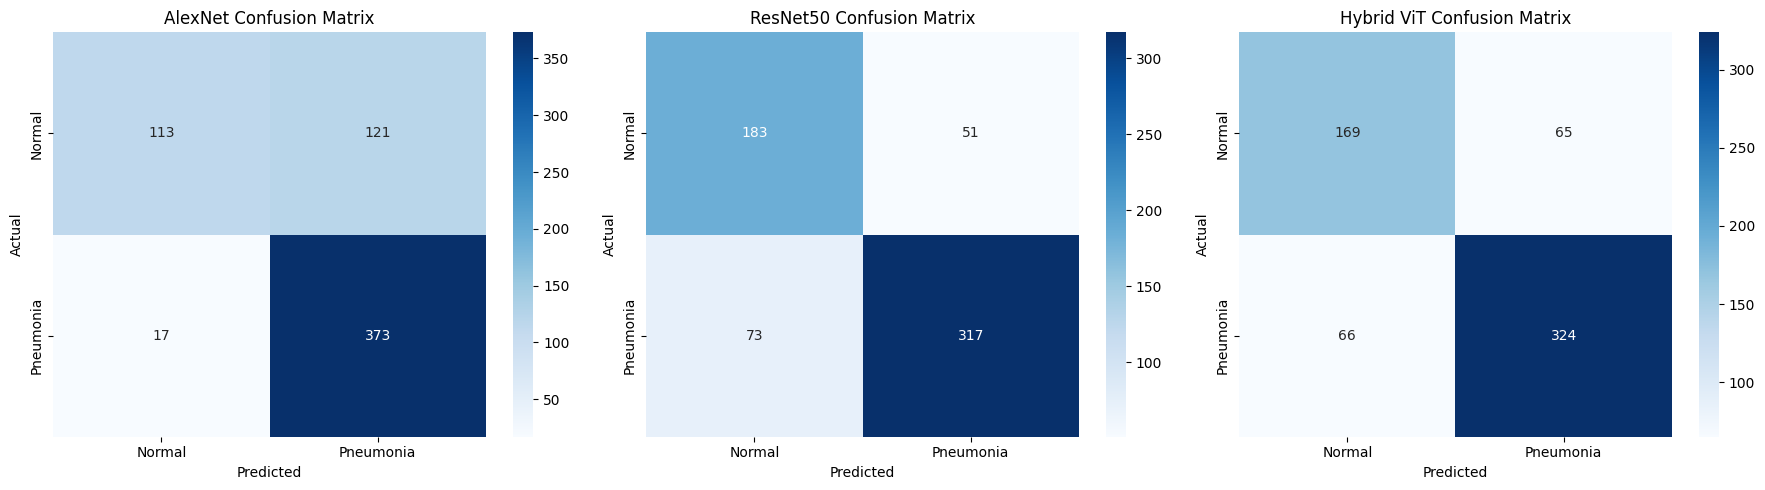

In [ ]:
# A. Confusion Matrix
plt.figure(figsize=(18, 5))
for i, (name, (yt, yp)) in enumerate(confusion_data.items()):
    plt.subplot(1, 3, i+1)
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
    plt.title(f"{name} Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

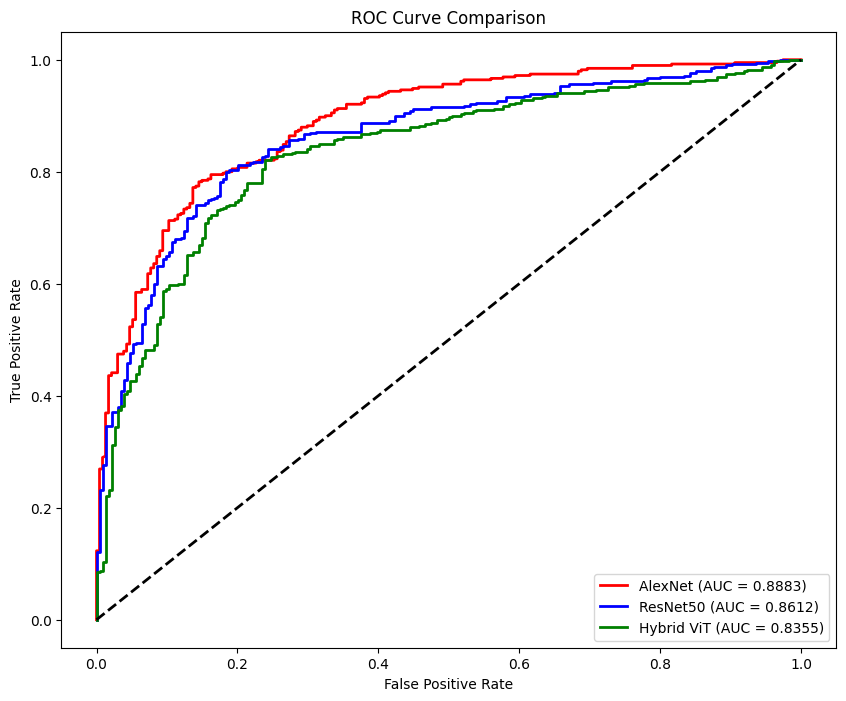

In [ ]:
# B. ROC Curve
plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green']
for i, (name, (yt, yprob)) in enumerate(roc_data.items()):
    fpr, tpr, _ = roc_curve(yt, yprob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()


--- BƯỚC 4: ERROR ANALYSIS (HYBRID MODEL) ---
Số ca False Negative (Sót bệnh): 66


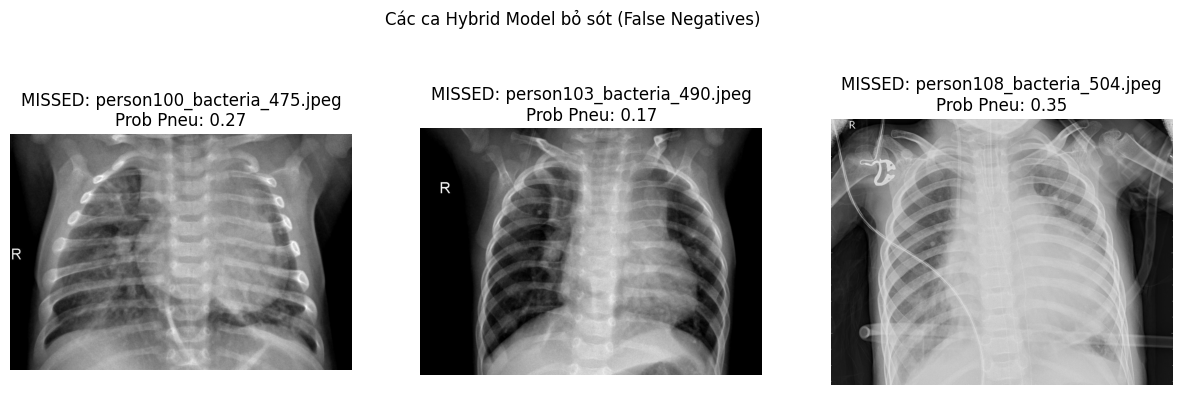

In [ ]:
# 6. ERROR ANALYSIS (PHÂN TÍCH LỖI TRÊN HYBRID MODEL)
# ==============================================================================
if hybrid_info:
    print("\n--- BƯỚC 4: ERROR ANALYSIS (HYBRID MODEL) ---")
    y_true = hybrid_info['y_true']
    y_pred = hybrid_info['y_pred']
    probs = hybrid_info['y_prob']
    fnames = hybrid_info['filenames']

    # Tìm các ca False Negative (Bị bệnh mà đoán là Normal) - Nguy hiểm nhất
    fn_indices = np.where((y_true == 1) & (y_pred == 0))[0]
    print(f"Số ca False Negative (Sót bệnh): {len(fn_indices)}")

    if len(fn_indices) > 0:
        plt.figure(figsize=(15, 5))
        # Lấy tối đa 3 ảnh để show
        for i, idx in enumerate(fn_indices[:3]):
            img_path = os.path.join(TEST_DIR, fnames[idx])
            img = plt.imread(img_path)
            plt.subplot(1, 3, i+1)
            plt.imshow(img, cmap='gray')
            plt.title(f"MISSED: {fnames[idx].split('/')[-1]}\nProb Pneu: {probs[idx]:.2f}")
            plt.axis('off')
        plt.suptitle("Các ca Hybrid Model bỏ sót (False Negatives)")
        plt.show()


--- BƯỚC 5: GRAD-CAM VISUALIZATION ---


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


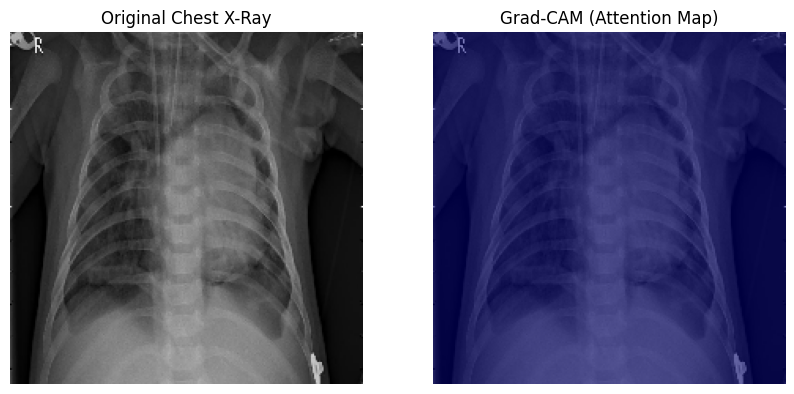

✅ Đã vẽ thành công Grad-CAM!

!!! HOÀN TẤT ĐÁNH GIÁ !!!


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1133, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 113, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

In [ ]:
# 7. GRAD-CAM (CHO HYBRID MODEL)
print("\n--- BƯỚC 5: GRAD-CAM VISUALIZATION ---")
path_hybrid = model_paths.get('Hybrid ViT')

if path_hybrid and os.path.exists(path_hybrid):
    try:
        model = tf.keras.models.load_model(path_hybrid)

        # Chọn 1 ảnh True Positive (Đoán đúng bệnh) để soi
        tp_indices = np.where((hybrid_info['y_true'] == 1) & (hybrid_info['y_pred'] == 1))[0]

        if len(tp_indices) > 0:
            idx = tp_indices[0] # Lấy ảnh đầu tiên
            img_path = os.path.join(TEST_DIR, hybrid_info['filenames'][idx])

            # Preprocess
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0) / 255.0

            # Tên layer cuối của ResNet50 (thường là 'conv5_block3_out')
            # LƯU Ý: Vì Hybrid dùng backbone ResNet, ta cần tìm đúng layer
            target_layer = 'conv5_block3_out'

            heatmap = make_gradcam_heatmap(img_array, model, target_layer)

            if heatmap is not None:
                plt.figure(figsize=(10, 5))
                plt.subplot(1, 2, 1)
                plt.imshow(img)
                plt.title("Original Chest X-Ray")
                plt.axis('off')

                plt.subplot(1, 2, 2)
                plt.imshow(img)
                plt.imshow(cv2.resize(heatmap, (224, 224)), alpha=0.5, cmap='jet')
                plt.title("Grad-CAM (Attention Map)")
                plt.axis('off')
                plt.show()
                print("✅ Đã vẽ thành công Grad-CAM!")
            else:
                print("⚠️ Không tạo được Heatmap (Có thể do tên layer không khớp).")

        del model
        gc.collect()

    except Exception as e:
        print(f"⚠️ Lỗi phần Grad-CAM: {e}")
else:
    print("⚠️ Không tìm thấy model Hybrid để chạy Grad-CAM.")

print("\n!!! HOÀN TẤT ĐÁNH GIÁ !!!")

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np
import cv2
from PIL import Image
import uuid
from datetime import datetime
import os

import tensorflow as tf
import os

print("Đang tải model phát hiện viêm phổi từ X-quang phổi...")

model_path = "/kaggle/input/model-demo/keras/default/1/model_demo.h5"

if os.path.exists(model_path):
    print(f"Model được tìm thấy tại: {model_path}")
else:
    print(f"Lỗi: Không tìm thấy model tại {model_path}. Kiểm tra path input!")
    raise FileNotFoundError(f"Model file not found: {model_path}")

# Load model
model = tf.keras.models.load_model(model_path)

print("Model đã sẵn sàng! (Binary: NORMAL vs PNEUMONIA)")

# 2. GRAD-CAM (sửa layer name chuẩn cho ResNet50)
# =========================================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out"):
    # Tạo sub-model để lấy conv output + prediction
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # Loss là xác suất lớp Pneumonia (index 0 vì binary sigmoid)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# =========================================================
# 3. DIAGNOSTIC PIPELINE (chính)
# =========================================================
def diagnostic_pipeline(img, show_heatmap=True):
    if img is None:
        return None, None, "<div style='color:white;'>Vui lòng upload ảnh X-quang.</div>", None, None, None

    # --- Metadata ---
    patient_id = f"CASE-{uuid.uuid4().hex[:8].upper()}"
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # --- Preprocess ---
    orig_img = np.array(img.convert("RGB"))
    resized = img.resize((224, 224)).convert("RGB")
    img_array = np.array(resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

    # --- Prediction ---
    prob = float(model.predict(img_array)[0][0])
    is_pneumonia = prob >= 0.5
    confidence = prob if is_pneumonia else (1 - prob)

    # --- Risk Level ---
    if confidence < 0.6:
        risk = "LOW"
        risk_color = "#22c55e"
    elif confidence < 0.85:
        risk = "MEDIUM"
        risk_color = "#facc15"
    else:
        risk = "HIGH"
        risk_color = "#ef4444"

    label = "PNEUMONIA DETECTED" if is_pneumonia else "NORMAL"

    # --- Grad-CAM (nếu bật) ---
    gradcam_img = None
    if show_heatmap:
        try:
            heatmap = make_gradcam_heatmap(img_array, model)
            heatmap = cv2.resize(heatmap, (orig_img.shape[1], orig_img.shape[0]))
            heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_HOT)
            gradcam_img = cv2.addWeighted(orig_img, 0.45, heatmap, 0.55, 0)
        except Exception as e:
            print(f"Grad-CAM error: {e}")
            gradcam_img = orig_img  # Fallback

    # --- Result Card HTML (dark mode) ---
    status_html = f"""
    <div style="
        background:##f1f5f9;
        border-left:8px solid #22c55e;
        padding:20px;
        border-radius:14px;
        box-shadow:0 10px 30px rgba(34,197,94,0.2);
        color:#e2e8f0;
    ">
        <h2 style="margin:0;color:#22c55e;">{label}</h2>
        <p><b>Confidence:</b> {confidence*100:.2f}%</p>
        <p><b>Risk Level:</b> <span style="color:#22c55e;font-weight:700;">{risk}</span></p>
        <hr style="border-color:#334155;">
        <p><b>Patient ID:</b> {patient_id}</p>
        <p><b>Timestamp:</b> {timestamp}</p>
    </div>
    """

    # --- Save report ---
    report_path = f"/kaggle/working/{patient_id}_report.txt"
    with open(report_path, "w") as f:
        f.write(
            f"Patient ID: {patient_id}\n"
            f"Timestamp: {timestamp}\n"
            f"Result: {label}\n"
            f"Confidence: {confidence*100:.2f}%\n"
            f"Risk Level: {risk}\n"
        )

    return (
        orig_img,
        gradcam_img if gradcam_img is not None else orig_img,
        status_html,
        {"Pneumonia": prob, "Normal": 1 - prob},
        report_path,
        patient_id
    )

# =========================================================
# 4. UI – DARK MODE HOSPITAL DASHBOARD
# =========================================================
with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="blue",
        neutral_hue="slate",
        font=["Inter", "system-ui"]
    ),
    css="""
    body { background:#020617; color:white; }
    h1,h2,h3 { letter-spacing:-0.02em; }
    .footer { text-align:center; font-size:13px; color:#94a3b8; margin-top:20px; }
    """
) as demo:
    gr.Markdown("""
    <h1 style="text-align:center;">🩺 PNEUMO-VISION AI</h1>
    <p style="text-align:center;color:#94a3b8;">
    Clinical Decision Support System for Pneumonia Detection from Chest X-ray
    </p>
    """)

    with gr.Row():
        with gr.Column(scale=4):
            input_img = gr.Image(type="pil", label="Upload Chest X-ray Image")
            heatmap_opt = gr.Checkbox(label="Enable Explainable AI (Grad-CAM)", value=True)
            run_btn = gr.Button("Run Clinical Analysis", variant="primary")

        with gr.Column(scale=8):
            res_html = gr.HTML()
            with gr.Row():
                orig_view = gr.Image(label="Original X-ray")
                cam_view = gr.Image(label="Grad-CAM Heatmap (Attention on Lesion)")
            conf_label = gr.Label(label="Probability Scores")
            report_file = gr.File(label="Download Clinical Report (TXT)")
            case_id = gr.Textbox(label="Patient / Case ID", interactive=False)

    gr.Markdown("""
    <div class="footer">
    ⚠️ For research & educational use only. Not for standalone medical diagnosis.
    Model trained on Kaggle Chest X-Ray Pneumonia dataset.
    </div>
    """)

    run_btn.click(
        fn=diagnostic_pipeline,
        inputs=[input_img, heatmap_opt],
        outputs=[orig_view, cam_view, res_html, conf_label, report_file, case_id]
    )

demo.launch(share=True)  # share=True để có public link nếu cần demo

Đang tải model phát hiện viêm phổi từ X-quang phổi...
Model được tìm thấy tại: /kaggle/input/model-demo/keras/default/1/model_demo.h5


2026-01-17 01:40:58.978339: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model đã sẵn sàng! (Binary: NORMAL vs PNEUMONIA)
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://3115d821000b08740c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Improve**

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB2  # ← Improved backbone
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from pathlib import Path

In [ ]:
# Suppress warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# 1. Paths on Kaggle (dataset tự động mount)
base_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')
val_dir = os.path.join(base_dir, 'val')

print("Folders in dataset:", os.listdir(base_dir))

Folders in dataset: ['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [ ]:
# 2. Re-split (Merge val into train, stratified split 80-10-10)
train_normal = glob.glob(os.path.join(train_dir, 'NORMAL/*.jpeg'))
train_pneumonia = glob.glob(os.path.join(train_dir, 'PNEUMONIA/*.jpeg'))
val_normal = glob.glob(os.path.join(val_dir, 'NORMAL/*.jpeg'))
val_pneumonia = glob.glob(os.path.join(val_dir, 'PNEUMONIA/*.jpeg'))

all_normal = train_normal + val_normal
all_pneumonia = train_pneumonia + val_pneumonia

df_normal = pd.DataFrame({'path': all_normal, 'label': 'NORMAL'})
df_pneumonia = pd.DataFrame({'path': all_pneumonia, 'label': 'PNEUMONIA'})
df_merged = pd.concat([df_normal, df_pneumonia], ignore_index=True)

# Split 80% train, 10% val, 10% test
train_df, temp_df = train_test_split(df_merged, test_size=0.2, stratify=df_merged['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print("Train:", train_df['label'].value_counts())
print("Val:", val_df['label'].value_counts())
print("Test:", test_df['label'].value_counts())

Train: label
PNEUMONIA    3106
NORMAL       1079
Name: count, dtype: int64
Val: label
PNEUMONIA    388
NORMAL       135
Name: count, dtype: int64
Test: label
PNEUMONIA    389
NORMAL       135
Name: count, dtype: int64


In [ ]:
import os
print("Các dataset hiện có:", os.listdir("/kaggle/input/"))
print("Nội dung trong chest-xray-pneumonia:", os.listdir("/kaggle/input/chest-xray-pneumonia"))
print("Nội dung trong chest_xray:", os.listdir("/kaggle/input/chest-xray-pneumonia/chest_xray"))

Các dataset hiện có: ['model-demo', 'improved-saved-keras', 'improved-saved-h5', 'alexnet-improved-saved-keras', 'alexnet-keras', 'chest-xray-pneumonia', 'hybrid-vit', 'resnet50']
Nội dung trong chest-xray-pneumonia: ['chest_xray']
Nội dung trong chest_xray: ['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [ ]:
# 4. Strong Augmentation (Boafo 2024 style)
IMG_SIZE = (260, 260)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    shear_range=0.1,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Tạo generators
train_gen = train_datagen.flow_from_directory(
    data_path / 'train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    data_path / 'val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    data_path / 'test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nGenerators created successfully!")
print(f"Train samples: {train_gen.samples} | Classes: {train_gen.class_indices}")

# Class weights (tính từ generator, không cần train_df)
labels = train_gen.classes
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

# Callbacks (focus on recall)
callbacks = [
    EarlyStopping(monitor='val_recall', patience=10, mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model_improved.keras', monitor='val_recall', save_best_only=True, mode='max', verbose=1)
]

# Focal Loss
focal_loss = BinaryFocalCrossentropy(alpha=0.25, gamma=2.0)

print("\nSetup hoàn tất! Sẵn sàng train model.")

✅ Dataset tồn tại!
Nội dung chest_xray: ['chest_xray', '__MACOSX', 'val', 'test', 'train']
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

Generators created successfully!
Train samples: 5216 | Classes: {'NORMAL': 0, 'PNEUMONIA': 1}
Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}

Setup hoàn tất! Sẵn sàng train model.


In [ ]:
def build_model(self):
        """
        Cải tiến 3: Backbone EfficientNetB2 + Head classifier mạnh hơn
        """
        print("\n🏗️ Bước 2: Xây dựng Model Improved...")
        base_model = EfficientNetB2(
            weights='imagenet',
            include_top=False,
            input_shape=(self.img_size, self.img_size, 3)
        )
        base_model.trainable = False  # Phase 1: Freeze để train nhanh

        self.model = Sequential([
            base_model,
            GlobalAveragePooling2D(),
            BatchNormalization(),
            Dense(512, activation='swish'),  # Swish tốt hơn ReLU cho EfficientNet
            Dropout(0.45),
            BatchNormalization(),
            Dense(256, activation='swish'),
            Dropout(0.35),
            Dense(1, activation='sigmoid')
        ])

        self.model.compile(
            optimizer=Adam(learning_rate=1e-3),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC(name='auc')]
        )

        print("   ✅ Model built! Params:", f"{self.model.count_params():,}")
        return self.model

In [ ]:
# 6. CONFIG & TRAIN (ĐÃ SỬA METRICS & CALLBACKS)
# 1. Callbacks (Canh theo 'val_recall' chữ thường)
callbacks = [
    EarlyStopping(monitor='val_recall', patience=12, mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint(
        '/kaggle/working/best_hybrid_model.keras',
        monitor='val_recall',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

# 2. Metrics
METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc')
]

# Focal Loss
focal_loss = tf.keras.losses.BinaryFocalCrossentropy(alpha=0.25, gamma=2.0)

In [ ]:
print(">>> BẮT ĐẦU TRAIN LẠI...")

# --- AlexNet ---
    def train_model(self, train_gen, val_gen, epochs=35):
        """
        Cải tiến 4: Train 2 phase + Monitor Recall (ưu tiên phát hiện bệnh)
        """
        print("\n--- Training AlexNet Improved ---")

        callbacks = [
            ModelCheckpoint(
                '/kaggle/working/best_improved_model.keras',
                monitor='val_recall', mode='max', save_best_only=True, verbose=1
            ),
            EarlyStopping(monitor='val_recall', patience=10, mode='max', restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
        ]

        # Phase 1: Frozen base
        print("   Phase 1: Freeze base model...")
        self.history = self.model.fit(
            train_gen, validation_data=val_gen, epochs=epochs, callbacks=callbacks, verbose=1
        )

        # Phase 2: Fine-tune
        print("\n   Phase 2: Unfreeze & fine-tune top layers...")
        base_model = self.model.layers[0]
        base_model.trainable = True
        fine_tune_at = len(base_model.layers) // 2  # Unfreeze ~50% layers
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

        self.model.compile(
            optimizer=Adam(learning_rate=5e-6),  # LR rất nhỏ để ổn định
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC(name='auc')]
        )

        self.history_phase2 = self.model.fit(
            train_gen, validation_data=val_gen,
            epochs=20,
            initial_epoch=len(self.history.history['loss']),
            callbacks=callbacks,
            verbose=1
        )

>>> BẮT ĐẦU TRAIN LẠI (ĐÃ FIX TOÀN BỘ)...

--- Training AlexNet Improved ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6493 - loss: 1.4492 - precision: 0.8327 - recall: 0.6558
Epoch 1: val_recall improved from -inf to 1.00000, saving model to /kaggle/working/best_improved.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 437s 3s/step - accuracy: 0.6497 - loss: 1.4461 - precision: 0.8330 - recall: 0.6561 - val_accuracy: 0.7419 - val_loss: 0.8447 - val_precision: 0.7419 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7594 - loss: 0.5056 - precision: 0.8939 - recall: 0.7682
Epoch 2: val_recall did not improve from 1.00000
131/131 ━━━━━━━━━━━━━━━━━━━━ 429s 3s/step - accuracy: 0.7595 - loss: 0.5052 - precision: 0.8940 - recall: 0.7682 - val_accuracy: 0.7419 - val_loss: 1.6170 - val_precision: 0.7419 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7691 - loss: 0.4161 - precision: 0.9000 - recall: 0.7755
Epoch 3: val_recall did no

In [ ]:
print("Các dataset đang có trong /kaggle/input/:")
print(os.listdir("/kaggle/input/"))

Các dataset đang có trong /kaggle/input/:
['model-demo', 'improved-saved-keras', 'improved-saved-h5', 'alexnet-improved-saved-keras', 'alexnet-keras', 'chest-xray-pneumonia', 'hybrid-vit', 'resnet50']


In [ ]:
MODEL_PATH = "/kaggle/input/improved-saved-h5/keras/default/1/improved_saved.h5"